In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 242M/242M [01:02<00:00, 4.07MB/s]

Extracting files...


Path to dataset files: C:\Users\jiya jain\.cache\kagglehub\datasets\snap\amazon-fine-food-reviews\versions\2


In [17]:
import pandas as pd
file_path = "C:/Users/jiya jain/Documents/GitHub/helpful_review_prediction/amazon-fine-food-reviews/versions/2/Reviews.csv"

df = pd.read_csv(file_path, nrows=10000)
print(df.columns)
df

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
9995,9996,B000P41A28,A3A63RACXR1XIL,"A. Boodhoo ""deaddodo""",10,15,1,1204502400,constipation,we switched from the advance similac to the or...
9996,9997,B000P41A28,A5VVRGL8JA7R,Adam,2,3,5,1306368000,Constipation Not A Problem if...,"Like the bad reviews say, the organic formula ..."
9997,9998,B000P41A28,A2TGDTJ8YCU6PD,geena77,0,0,5,1347494400,Love this formula!,I wanted to solely breastfeed but was unable t...
9998,9999,B000P41A28,AUV4GIZZE693O,"Susan Coe ""sueysis""",1,2,5,1203638400,very convenient,i love the fact that i can get this delieved t...


In [18]:
df_filtered = df[df['HelpfulnessDenominator'] > 0].copy()
df_filtered['is_helpful'] = (df_filtered['HelpfulnessNumerator'] / df_filtered['HelpfulnessDenominator'] > 0.5).astype(int)

print(df_filtered['is_helpful'].value_counts())

is_helpful
1    3841
0    1281
Name: count, dtype: int64


In [15]:
df_filtered

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,is_helpful
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,1
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,1
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,1
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...,1
10,11,B0001PB9FE,A3HDKO7OW0QNK4,Canadian Fan,1,1,5,1107820800,The Best Hot Sauce in the World,I don't know if it's the cactus or the tequila...,1
...,...,...,...,...,...,...,...,...,...,...,...
9994,9995,B000P41A28,A350OL4V8DV5YK,Helen Avramenko,3,4,5,1259539200,great product,I switched from Similac Advanced to Organic wh...,1
9995,9996,B000P41A28,A3A63RACXR1XIL,"A. Boodhoo ""deaddodo""",10,15,1,1204502400,constipation,we switched from the advance similac to the or...,1
9996,9997,B000P41A28,A5VVRGL8JA7R,Adam,2,3,5,1306368000,Constipation Not A Problem if...,"Like the bad reviews say, the organic formula ...",1
9998,9999,B000P41A28,AUV4GIZZE693O,"Susan Coe ""sueysis""",1,2,5,1203638400,very convenient,i love the fact that i can get this delieved t...,0


In [20]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_review(text):
    text = re.sub(r'<.*?>', '', text) 
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.lower().split()
    useful_words = [w for w in words if w not in stop_words]
    
    return " ".join(useful_words)

df_filtered['CleanText'] = df_filtered['Text'].apply(clean_review)

print(df_filtered[['Text', 'CleanText']].head())

[nltk_data] Downloading package stopwords to C:\Users\jiya
[nltk_data]     jain\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                 Text  \
0   I have bought several of the Vitality canned d...   
2   This is a confection that has been around a fe...   
3   If you are looking for the secret ingredient i...   
8   Right now I'm mostly just sprouting this so my...   
10  I don't know if it's the cactus or the tequila...   

                                            CleanText  
0   bought several vitality canned dog food produc...  
2   confection around centuries light pillowy citr...  
3   looking secret ingredient robitussin believe f...  
8   right mostly sprouting cats eat grass love rot...  
10  know cactus tequila unique combination ingredi...  


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=7000)

X = tfidf.fit_transform(df_filtered['CleanText'])
y = df_filtered['is_helpful']

print(f"X shape: {X.shape}")

X shape: (5122, 7000)


In [49]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())

coefficients = model.coef_[0]

top_helpful = feature_names[np.argsort(coefficients)[-10:]]
top_unhelpful = feature_names[np.argsort(coefficients)[:10]]

print("Words that predict HELPFULNESS:", top_helpful)
print("Words that predict UNHELPFULNESS:", top_unhelpful)

Words that predict HELPFULNESS: ['one' 'amazon even' 'wrong' 'better tasting' 'good choice' 'food items'
 'dirty' 'mac cheese' 'love coffee' 'pains']
Words that predict UNHELPFULNESS: ['mg total' 'wide' 'balanced' 'arrive' 'chips try' 'substance' 'farmhouse'
 'diet' 'complete waste' 'calcium phosphorus']


In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'] 
}

grid = GridSearchCV(LogisticRegression(class_weight='balanced'), param_grid, cv=5, scoring='f1_weighted')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}


In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# 1. New Vectorizer with Bigrams
tfidf = TfidfVectorizer(max_features=7000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df_filtered['CleanText'])

# 2. Add the Length Feature back
X_final = hstack([X_tfidf, df_filtered['ReviewLength'].values.reshape(-1, 1)])

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [53]:
# 1. Initialize with your tuned parameters
best_model = LogisticRegression(C=10, solver='liblinear', class_weight='balanced')

# 2. Train
best_model.fit(X_train, y_train)

# 3. Evaluate
y_pred_final = best_model.predict(X_test)

print("Optimized Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred_final))

Optimized Logistic Regression Accuracy: 0.7307317073170732

Final Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.46      0.45       245
           1       0.83      0.82      0.82       780

    accuracy                           0.73      1025
   macro avg       0.63      0.64      0.64      1025
weighted avg       0.74      0.73      0.73      1025



In [54]:
feature_names = np.array(tfidf.get_feature_names_out().tolist() + ['ReviewLength'])
coefficients = best_model.coef_[0]

top_helpful = feature_names[np.argsort(coefficients)[-10:]]
top_unhelpful = feature_names[np.argsort(coefficients)[:10]]

print("Top Helpful Features:", top_helpful)
print("Top Unhelpful Features:", top_unhelpful)

Top Helpful Features: ['flavored coffee' 'consistency' 'flavored' 'amazing' 'years' 'brought'
 'perfect' 'delicious' 'little' 'stomach']
Top Unhelpful Features: ['melitta' 'worse' 'weak' 'may' 'doesnt' 'horses' 'great buy' 'bad'
 'love fact' 'amazon com']


In [55]:
def test_new_review(text):
    clean = clean_review(text)
    
    text_vector = tfidf.transform([clean])
    length = np.array([[len(text)]])
    combined = hstack([text_vector, length])
    prediction = best_model.predict(combined)
    
    # Output result
    return "Helpful" if prediction[0] == 1 else "Not Helpful"

print(test_new_review("This coffee is okay but the packaging was torn when it arrived."))

Helpful


In [56]:
import pickle

with open('helpful_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


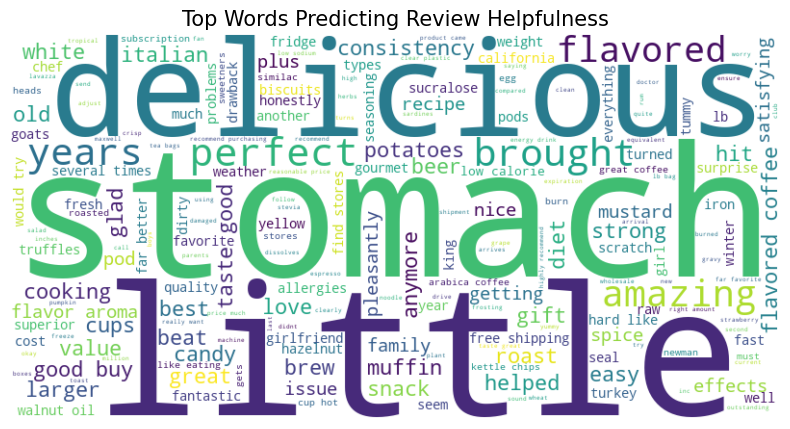

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

feature_names = tfidf.get_feature_names_out()
coefs = best_model.coef_[0][:len(feature_names)]
word_scores = dict(zip(feature_names, coefs))

helpful_words = {word: score for word, score in word_scores.items() if score > 0}

wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis').generate_from_frequencies(helpful_words)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Words Predicting Review Helpfulness', fontsize=15)
plt.show()